# Data Preparation -base table

## Data Source

The dataset consists of two CSV files exported from Salesforce.  
They were generated as a result of an email campaign with A/B testing (sent vs. not sent).  
Each file contains information about customers and their subscription behavior.

Due to Salesforce limitations, campaign data does not include the actual cancellation request date.
An additional report was used to extract **"Kündigung erfasst am"**, which reflects the true timing of churn.

## Imports
This section imports the necessary Python libraries for data processing and analysis.

In [30]:
import pandas as pd
from pathlib import Path
import re
import unicodedata
from statsmodels.stats.proportion import proportions_ztest

## Data Loading
In this section, two CSV files from the A/B test campaign are loaded and combined into a single dataset.
It was also loaded the CSV file with timing of churn.
`cancel_date` is used for analysis instead of `end_date` to avoid time lag bias (~1 month delay between request and contract end).

In [31]:
base_path = Path("../Data/raw")

read_kwargs = {
    "sep": ";",
    "dtype": {"SAP GP Nummer": "string"}
}

# load campaign datasets (treatment / control)
df1 = pd.read_csv(base_path / "Kampagnenmitglieder_nein_raw.csv", **read_kwargs)
df2 = pd.read_csv(base_path / "Kampagnenmitglieder_ja_raw.csv", **read_kwargs)

# load cancellation request data ("Kündigung erfasst am")
df_kuend = pd.read_csv(base_path / "Kuendigung erfasst am-2026-04-22-15-57-421.csv", **read_kwargs)

# keep relevant columns from campaign data
relevant_cols = [
    "SAP GP Nummer",
    "letzter Abo - Auftrag: Auftrag von",
    "letzter Abo - Auftrag: Auftrag bis",
    "letzter Abo - Auftrag: Kündigungsgrund Code"
]

df1_clean = df1[relevant_cols].copy()
df2_clean = df2[relevant_cols].copy()

# add treatment indicator
df1_clean["treatment"] = 0
df2_clean["treatment"] = 1

# combine groups
df = pd.concat([df1_clean, df2_clean], ignore_index=True)

# rename columns
df = df.rename(columns={
    "SAP GP Nummer": "customer_id",
    "letzter Abo - Auftrag: Auftrag von": "start_date",
    "letzter Abo - Auftrag: Auftrag bis": "end_date",
    "letzter Abo - Auftrag: Kündigungsgrund Code": "cancel_reason"
})

# keep relevant columns from cancellation dataset
df_kuend_clean = df_kuend[[
    "SAP GP Nummer",
    "letzter Abo - Auftrag: Kündigung erfasst am",
    "zuletzt aktiv Portal"
]].copy()

df_kuend_clean = df_kuend_clean.rename(columns={
    "SAP GP Nummer": "customer_id",
    "letzter Abo - Auftrag: Kündigung erfasst am": "cancel_date",
})

for col in df.columns:
    print(col)


for col in df_kuend_clean.columns:
    print(col)


customer_id
start_date
end_date
cancel_reason
treatment
customer_id
cancel_date
zuletzt aktiv Portal


## data type harmonization

In [32]:
# unify key type
df["customer_id"] = df["customer_id"].astype(str).str.strip()
df_kuend_clean["customer_id"] = df_kuend_clean["customer_id"].astype(str).str.strip()

# convert dates
df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce", dayfirst=True)
df["end_date"] = pd.to_datetime(df["end_date"], errors="coerce", dayfirst=True)
df_kuend_clean["cancel_date"] = pd.to_datetime(
    df_kuend_clean["cancel_date"], errors="coerce", dayfirst=True
)

# inspect column types
print(df.dtypes)
print("\n--- df_kuend_clean ---\n")
print(df_kuend_clean.dtypes)

customer_id                 str
start_date       datetime64[us]
end_date         datetime64[us]
cancel_reason               str
treatment                 int64
dtype: object

--- df_kuend_clean ---

customer_id                        str
cancel_date             datetime64[us]
zuletzt aktiv Portal               str
dtype: object


## deduplication 

In [33]:
# total number of rows
len(df)

# number of duplicated customer_ids
df["customer_id"].duplicated().sum()

# difference between total rows and unique customers (should be 0 if no duplicates)
len(df) - df["customer_id"].nunique()

# before deduplication
print("rows before:", len(df_kuend_clean))
print("duplicate customer_ids:", df_kuend_clean["customer_id"].duplicated().sum())

# deduplication
df_kuend_clean = (
    df_kuend_clean
    .sort_values("cancel_date")
    .drop_duplicates("customer_id", keep="first")
)

# after deduplication
print("rows after:", len(df_kuend_clean))
print("duplicate customer_ids after:", df_kuend_clean["customer_id"].duplicated().sum())

# check duplicate customers in campaign data
customer_counts = df["customer_id"].value_counts()

print("customers with more than one row:", (customer_counts > 1).sum())
print("duplicate rows:", df["customer_id"].duplicated().sum())
customer_counts[customer_counts > 1].head(20)

rows before: 2295
duplicate customer_ids: 0
rows after: 2295
duplicate customer_ids after: 0
customers with more than one row: 0
duplicate rows: 0


Series([], Name: count, dtype: int64)

## dataset construction

In [34]:
# merge
df = df.merge(df_kuend_clean, on="customer_id", how="left")

# check number of rows
print("rows after merge:", len(df))
df.head()


rows after merge: 28566


,customer_id,start_date,end_date,cancel_reason,treatment,cancel_date,zuletzt aktiv Portal
0,0018640485,2022-12-05,NaT,NaN,0,NaT,NaN
1,0018703242,2026-04-14,2028-04-13,BEF,0,NaT,NaN
2,0019173245,2026-04-01,NaT,NaN,0,NaT,NaN
3,0019173659,2021-01-01,NaT,NaN,0,NaT,NaN
4,0019173423,2025-10-01,NaT,NaN,0,NaT,NaN


## date issues

In [35]:
# check date issues

today = pd.Timestamp.today().normalize()

# future dates
future_start = df["start_date"] > today
future_cancel = df["cancel_date"] > today

print("start_date future:", future_start.sum())
print("cancel_date future:", future_cancel.sum())

# wrong order
wrong_order = (
    df["start_date"].notna() &
    df["end_date"].notna() &
    (df["end_date"] < df["start_date"])
)

print("end_date < start_date:", wrong_order.sum())

# show problematic rows
problem_rows = df[
    future_start | future_cancel | wrong_order
][["customer_id", "start_date", "end_date", "cancel_date"]]

problem_rows.sort_values("customer_id").head(20)

# --- remove invalid rows ---

df_clean = df[
    (~future_start) & 
    (~future_cancel) & 
    (~wrong_order)
].copy()

start_date future: 1
cancel_date future: 0
end_date < start_date: 0


## sample definition
### Exclude cancellations with technical or exogenous reasons:
- AKP – downgrade due to age/health/care-related reasons 
- GPW – customer ID change (technical)
- KIN – internal contract transitions
- KOR – correction (technical adjustment)
- KZA – cancellation due to non-payment
- KÜP – cancellation withdrawal via portal
- KÜR – cancellation with retention attempt (win-back)
- LEG – life circumstances changed
- TOD – deceased
- UMZ – relocation (move)

In [36]:
# show all unique cancellation reasons
df["cancel_reason"].dropna().sort_values().unique()

<StringArray>
['AKP', 'AME', 'AZE', 'BEF', 'BES', 'BON', 'DPB', 'DPZ', 'FIN', 'GPW', 'INH',
  'KA',  'KI', 'KIN', 'KOR', 'KZA', 'KZE', 'KÜP', 'KÜR', 'LEG', 'NZU', 'PRE',
 'PSL', 'SER', 'TEC', 'TOD', 'TRE', 'UMZ', 'WID']
Length: 29, dtype: str

In [37]:
# examples KIN
df[df["cancel_reason"] == "KIN"][
    ["customer_id", "start_date", "end_date", "cancel_reason"]
].head(5)

,customer_id,start_date,end_date,cancel_reason
1798,0019300717,2026-04-02,2026-04-30,KIN
2945,0019264071,2024-05-02,2026-05-01,KIN
4047,0019335639,2024-06-27,2026-06-26,KIN
4471,0019541568,2026-01-01,2026-03-31,KIN
5041,0019605306,2026-01-01,2026-04-07,KIN


In [38]:
# reasons to exclude
exclude_reasons = ["GPW", "KIN", "KOR", "KZA", "TOD", "UMZ"]

counts = (
    df["cancel_reason"]
    .value_counts(dropna=False)
    .loc[lambda x: x.index.isin(exclude_reasons)]
)

print("=== EXCLUSION CRITERIA CHECK ===")
print(counts)

# filtering
df = df[~df["cancel_reason"].isin(exclude_reasons)].copy()

# report AFTER
print("\n=== AFTER FILTERING ===")
print("rows remaining:", len(df))

=== EXCLUSION CRITERIA CHECK ===
cancel_reason
KIN    32
TOD    30
UMZ    24
KZA    21
GPW     1
KOR     1
Name: count, dtype: int64

=== AFTER FILTERING ===
rows remaining: 28457


In [39]:
print(df["cancel_date"].notna().sum())

344


# Data Preparation - feature table and output table

## Data Source 
The feature table is provided as a CSV file compiled from BigQuery, where data is ingested via event streams from digital platforms, 
as well as integrated sources such as Salesforce and SAP.

## Data Loading

In [40]:
read_kwargs = {
    "sep": ";",
    "dtype": {"SAP GP Nummer": "string"},
    "decimal": ","
}

base_path = Path("../data")
df_features_raw = pd.read_csv(base_path / "features" / "pay_features.csv", **read_kwargs)
df_reaction_raw = pd.read_csv(base_path / "features" / "reaktion.csv", **read_kwargs)
df_tenure_raw = pd.read_csv(base_path / "features" / "datum_erster.csv", **read_kwargs)

df_reaction_raw["SAP GP Nummer"] = (
    df_reaction_raw["SAP GP Nummer"]
    .astype("string")
    .str.strip()
    .str.zfill(10)
)

df_tenure_raw["SAP GP Nummer"] = (
    df_tenure_raw["SAP GP Nummer"]
    .astype("string")
    .str.strip()
    .str.zfill(10)
)

# basic info
print("=== ROW COUNTS ===")
print(f"features:  {len(df_features_raw)}")
print(f"reaction:  {len(df_reaction_raw)}")

print("\n=== DUPLICATES ===")
print("features:", df_features_raw["SAP GP Nummer"].duplicated().sum())
print("reaction:", df_reaction_raw["SAP GP Nummer"].duplicated().sum())

=== ROW COUNTS ===
features:  28564
reaction:  23378

=== DUPLICATES ===
features: 0
reaction: 0


In [41]:
# show all columns

print("=== FEATURES ===")
for col in df_features_raw.columns:
    print(col)

print("\n=== REACTION ===")
for col in df_reaction_raw.columns:
    print(col)

print("\n=== TENURE ===")
for col in df_tenure_raw.columns:
    print(col)

=== FEATURES ===
Accountname
SAP GP Nummer
E-Mail-Kontakt
letzter Abo - Auftrag: Auftrag von
letzter Abo - Auftrag: Auftrag bis
letzter Abo - Auftrag: Kündigungsgrund Code
Produkt / Abo-Status
letzter Abo - Auftrag: Fakturaperiodizität Code
letzter Abo - Auftrag: Zahlweg
letzter Abo - Auftrag: Bezugsgrund Code
letzter Abo - Auftrag: Werbeträger
Anrede
Geburtsdatum
Kundencluster Vertrieb
Sozialmilieu
Telefon privat
Telefon mobil
Haltbarkeit letzte Beziehung
Kumulierte Haltbarkeit
zuletzt aktiv Portal
zuletzt aktiv News App
zuletzt aktiv E-Paper Web
zuletzt aktiv E-Paper App
Nutzung E-Paper App
Nutzung E-Paper Web
Nutzung News App
Nutzung Portal

=== REACTION ===
Emailing (geklickt)
Emailing (geöffnet)
SAP GP Nummer

=== TENURE ===
SAP GP Nummer
erster Abo-Beginn


## rename columns

In [42]:
# rename raw columns for feature engineering

df_features_raw = df_features_raw.rename(columns={
    "SAP GP Nummer": "customer_id",

    # contract / subscription features
    "E-Mail-Kontakt": "allowed_email_contact",
    "Produkt / Abo-Status": "abo_status",
    "letzter Abo - Auftrag: Zahlweg": "payment_method",
    "letzter Abo - Auftrag: Auftrag bis": "end_date",
    "letzter Abo - Auftrag: Kündigungsgrund Code": "cancel_reason",
    "letzter Abo - Auftrag: Fakturaperiodizität Code": "billing_frequency",
    "letzter Abo - Auftrag: Bezugsgrund Code": "subscription_reason",
    "letzter Abo - Auftrag: Auftrag von": "contract_start_date",
    "letzter Abo - Auftrag: Werbeträger": "campaign_channel",

    # socio-demographic features
    "Geburtsdatum": "birth_date",
    "Anrede": "gender_raw",
    "Sozialmilieu": "milieu",
    "Kundencluster Vertrieb": "cluster",

    # engagement / contact features
    "zuletzt aktiv Portal": "last_portal",
    "zuletzt aktiv News App": "last_news",
    "zuletzt aktiv E-Paper Web": "last_epaper_web",
    "zuletzt aktiv E-Paper App": "last_epaper_app",
    "Nutzung E-Paper App": "use_epaper_app",
    "Nutzung E-Paper Web": "use_epaper_web",
    "Nutzung News App": "use_news",
    "Nutzung Portal": "use_portal",
    "Telefon privat": "phone_private",
    "Telefon mobil": "phone_mobile",

    # tenure features
    "Haltbarkeit letzte Beziehung": "current_tenure",
    "Kumulierte Haltbarkeit": "total_tenure"
})

df_reaction_raw = df_reaction_raw.rename(columns={
    "SAP GP Nummer": "customer_id",
    "Emailing (geklickt)": "email_clicked",
    "Emailing (geöffnet)": "email_opened"
})

df_tenure_raw = df_tenure_raw.rename(columns={
    "SAP GP Nummer": "customer_id", 
    "erster Abo-Beginn": "tenure_start_date"   
})

In [43]:
# --- show all columns ---

print("=== FEATURES ===")
for col in df_features_raw.columns:
    print(col)

print("\n=== REACTION ===")
for col in df_reaction_raw.columns:
    print(col)

print("\n=== TENURE ===")
for col in df_tenure_raw.columns:
    print(col)

=== FEATURES ===
Accountname
customer_id
allowed_email_contact
contract_start_date
end_date
cancel_reason
abo_status
billing_frequency
payment_method
subscription_reason
campaign_channel
gender_raw
birth_date
cluster
milieu
phone_private
phone_mobile
current_tenure
total_tenure
last_portal
last_news
last_epaper_web
last_epaper_app
use_epaper_app
use_epaper_web
use_news
use_portal

=== REACTION ===
email_clicked
email_opened
customer_id

=== TENURE ===
customer_id
tenure_start_date


## data type harmonization

In [44]:
df_features_raw["customer_id"] = df_features_raw["customer_id"].astype(str).str.strip()
df_reaction_raw["customer_id"] = df_reaction_raw["customer_id"].astype(str).str.strip()
df_features_raw["birth_date"] = pd.to_datetime(df_features_raw["birth_date"], errors="coerce")

df_features_raw["current_tenure"] = pd.to_numeric(df_features_raw["current_tenure"], errors="coerce")
df_features_raw["total_tenure"] = pd.to_numeric(df_features_raw["total_tenure"], errors="coerce")

df_tenure_raw["customer_id"] = df_tenure_raw["customer_id"].astype("string").str.strip()
df_tenure_raw["tenure_start_date"] = pd.to_datetime(
    df_tenure_raw["tenure_start_date"],
    errors="coerce",
    dayfirst=True
)

C:\Users\Professional\AppData\Local\Temp\ipykernel_53036\1433301683.py:3: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_features_raw["birth_date"] = pd.to_datetime(df_features_raw["birth_date"], errors="coerce")


## Feature preparation

### Age binning preparation

Age is calculated and cleaned to analyze its empirical distribution. The resulting distribution is used to define appropriate, data-driven age bins in the subsequent step.

In [45]:
today = pd.Timestamp("2026-04-19")
df_features_raw["age"] = (today - df_features_raw["birth_date"]).dt.days // 365

df_features_raw.loc[
    (df_features_raw["age"] < 18) | (df_features_raw["age"] > 97),
    "age"
] = pd.NA

df_features_raw["age"].describe()

count    27628.000000
mean        63.939554
std         11.371057
min         18.000000
25%         57.000000
50%         64.000000
75%         72.000000
max         97.000000
Name: age, dtype: float64

### Tenure preparation

Invalid placeholder values from legacy data are treated as missing. The cleaned data is then used to analyze the distribution and derive suitable bins.

In [46]:
df_tenure = df_features_raw.merge(
    df_tenure_raw[["customer_id", "tenure_start_date"]],
    on="customer_id",
    how="left"
)

top_dates = df_tenure["tenure_start_date"].value_counts().head(20)

print("=== TOP 20 tenure_start_date ===")
print(top_dates)

mask = df_tenure["tenure_start_date"] < pd.Timestamp("1970-01-01")
print("count:", mask.sum())

df_tenure.loc[
    df_tenure["tenure_start_date"] < pd.Timestamp("1970-01-01"),
    ["tenure_start_date", "customer_id"]
]

=== TOP 20 tenure_start_date ===
tenure_start_date
1978-03-02    430
1976-03-02    197
1977-02-18    141
1901-01-01    129
2002-11-25    125
2007-12-01    110
1970-01-01     85
2004-12-01     74
2003-04-22     71
2005-12-03     71
1993-05-03     68
2002-09-23     68
2004-12-04     67
2006-12-02     67
2003-12-02     62
1999-01-02     62
2003-04-14     60
1981-01-01     56
1978-11-01     56
2008-12-01     53
Name: count, dtype: int64
count: 163


,tenure_start_date,customer_id
246,1901-01-01,0016243671
348,1901-01-01,0016237004
528,1901-01-01,0016244511
534,1901-01-01,0016241868
552,1901-01-01,0016242493
...,...,...
27682,1968-04-01,0016201704
27711,1901-01-01,0016220211
27720,1901-01-01,0016207388
27943,1901-01-01,0015488595


## create model table

In [47]:
# create "contract_with_device" feature based on abo_status
df_model = df[["customer_id", "treatment"]].copy()

df_model = df_model.merge(
    df_features_raw[["customer_id", "abo_status"]],
    on="customer_id",
    how="left"
)

df_model["contract_with_device"] = (
    df_model["abo_status"]
    .str.contains("Gerät", case=False, na=False)
    .astype(int)
)

df_model = df_model.drop(columns=["abo_status"])

# report
print("=== contract_with_device ===")
print("with device (1):", df_model["contract_with_device"].sum())
print("without device (0):", (df_model["contract_with_device"] == 0).sum())
print("\n")



# create "payment_method" feature based on payment_method

mapping = {
    "3 - SEPA Bankeinzug (SEPA DD)": "SEPA",
    "8 - Zahlung via PayPal": "PayPal",
    "R - ISM - Rechnung": "Invoice",
    "7 - Zahlung via Kreditkarte": "CreditCard",
    "D - Dauerauftrag": "StandingOrder",
    "B - ISM - Bar/Kasse": "Cash"
}

df_model = df_model.merge(
    df_features_raw[["customer_id", "payment_method"]],
    on="customer_id",
    how="left"
)

df_model["payment_method"] = df_model["payment_method"].map(mapping)

# report
print("=== payment_method ===")
print(df_model["payment_method"].value_counts())



# create "billing_freq" feature based on billing_frequency

mapping = {
    "M": "M",  # monthly
    "Q": "Q",  # quarterly
    "H": "H",  # semiannual
    "J": "Y"   # yearly (Jahr)
}

df_model = df_model.merge(
    df_features_raw[["customer_id", "billing_frequency"]],
    on="customer_id",
    how="left"
)

df_model["billing_freq"] = df_model["billing_frequency"].map(mapping)
df_model["billing_freq"] = df_model["billing_freq"].fillna("U")  # unknown
df_model = df_model.drop(columns=["billing_frequency"])

# report

print("\n=== billing_freq ===")
print(df_model["billing_freq"].value_counts())



# create "age" feature based on birth_date  

df_model = df_model.merge(
    df_features_raw[["customer_id", "birth_date"]],
    on="customer_id",
    how="left"
)

bins = [18, 40, 55, 65, 75, 100]
df_model["age_bin"] = pd.cut(df_features_raw["age"], bins=bins)
df_model["age_bin"] = (
    df_model["age_bin"]
    .cat.add_categories("unknown")
    .fillna("unknown")
)
df_model = df_model.drop(columns=["birth_date"])
df_model["age_bin"] = df_model["age_bin"].astype("category")

# report

print("\n=== age_bin ===")
print(df_model["age_bin"].value_counts(dropna=False))




# create "gender" feature based on gender_raw  

df_model = df_model.merge(
    df_features_raw[["customer_id", "gender_raw"]],
    on="customer_id",
    how="left"
)

df_model["gender"] = df_model["gender_raw"].map({
    "H": "male",
    "F": "female",
    "O": "other",
    "U": "unknown"
})
df_model = df_model.drop(columns=["gender_raw"])

# report
print("\n=== gender ===")
print(df_model["gender"].value_counts())



# create "milieu" feature based on milieu  

df_model = df_model.merge(
    df_features_raw[["customer_id", "milieu"]],
    on="customer_id",
    how="left"
)

df_model["milieu"] = df_model["milieu"].replace("G", "unknown")
df_model["milieu"] = df_model["milieu"].fillna("unknown")

# report

print("\n === milieu ===")
print(df_model["milieu"].value_counts())



# create "cluster" feature based on cluster

df_model = df_model.merge(
    df_features_raw[["customer_id", "cluster"]],
    on="customer_id",
    how="left"
)
df_model["cluster"] = df_model["cluster"].fillna("unknown")

# report
print("\n=== cluster ===")
print(df_model["cluster"].value_counts())



# create "has_phone" feature based on phone_private and phone_mobile

df_model = df_model.merge(
    df_features_raw[["customer_id", "phone_private", "phone_mobile"]],
    on="customer_id",
    how="left"
)

df_model["has_phone"] = (
    df_model["phone_private"].notna() |
    df_model["phone_mobile"].notna()
).astype(int)
df_model = df_model.drop(columns=["phone_private", "phone_mobile"])

# report
print("\n=== has_phone ===")
print(df_model["has_phone"].value_counts())



# create "current_tenure", "total_tenure", "tenure_ratio" feature based on tenure_start_date, current_tenure and total_tenure

df_features_raw = df_features_raw.merge(
    df_tenure_raw[["customer_id", "tenure_start_date"]],
    on="customer_id",
    how="left"
)

df_model = df_model.merge(
    df_features_raw[["customer_id", "current_tenure", "total_tenure", "tenure_start_date"]],
    on="customer_id",
    how="left"
)

# remove invalid legacy placeholder dates
invalid_tenure = df_model["tenure_start_date"] < pd.Timestamp("1970-01-01")

df_model.loc[
    invalid_tenure,
    ["current_tenure", "total_tenure"]
] = pd.NA

# create tenure ratio
df_model["tenure_ratio"] = df_model["current_tenure"] / df_model["total_tenure"]

df_model.loc[
    (df_model["total_tenure"].isna()) | (df_model["total_tenure"] == 0),
    "tenure_ratio"
] = pd.NA

# report
print("\n=== tenure ===")
print(df_model[["current_tenure", "total_tenure", "tenure_ratio"]].describe())
print("invalid tenure rows:", invalid_tenure.sum())

df_model.head(5)

=== contract_with_device ===
with device (1): 1560
without device (0): 26897


=== payment_method ===
payment_method
SEPA             25249
Invoice           2442
PayPal             540
StandingOrder      144
CreditCard          73
Cash                 3
Name: count, dtype: int64

=== billing_freq ===
billing_freq
M    25388
Q     2753
H      160
Y      150
U        6
Name: count, dtype: int64

=== age_bin ===
age_bin
(55, 65]     9375
(65, 75]     8502
(40, 55]     4579
(75, 100]    4175
unknown       927
(18, 40]      899
Name: count, dtype: int64

=== gender ===
gender
male       16104
female     12228
other         82
unknown       41
Name: count, dtype: int64

 === milieu ===
milieu
PMA        3934
PER        3865
KOG        3534
ADA        3109
unknown    2800
NOB        2663
TRA        2102
EPE        1797
PRE        1741
NOK        1653
HED        1259
Name: count, dtype: int64

=== cluster ===
cluster
Floh           13791
Seehund         6427
Elefant         2587
Boese_Raupe  

,customer_id,treatment,contract_with_device,payment_method,billing_freq,age_bin,gender,milieu,cluster,has_phone,current_tenure,total_tenure,tenure_start_date,tenure_ratio
0,0018640485,0,0,SEPA,M,"(65, 75]",female,PMA,Floh,0,3.23,3.34,2012-10-25,0.967066
1,0018703242,0,0,Invoice,M,"(55, 65]",female,PER,Floh,0,6.64,6.83,2013-06-10,0.972182
2,0019173245,0,0,SEPA,M,"(55, 65]",female,NOK,Floh,0,6.42,6.71,2019-03-05,0.956781
3,0019173659,0,0,SEPA,M,"(75, 100]",male,PER,Seehund,0,7.00,7.00,2019-03-01,1.000000
4,0019173423,0,0,SEPA,M,"(75, 100]",female,EPE,Elefant,0,7.15,7.15,2019-03-01,1.000000


## create Opt-out Feature

### Email opt-out feature

1 if customer NOT allow Emails 

In [48]:
# merge email contact permission
df_model = df_model.merge(
    df_features_raw[["customer_id", "allowed_email_contact"]],
    on="customer_id",
    how="left"
)

# create email_optout flag:
# 1 = customer does NOT allow email contact
# 0 = customer allows email contact
df_model["email_optout"] = (
    df_model["allowed_email_contact"]
    .astype("string")
    .str.strip()
    .str.lower()
    .isin(["shzv-nein", "no", "0", "false"])
    .astype(int)
)

# drop raw column after feature creation
df_model = df_model.drop(columns=["allowed_email_contact"])

email_by_group = (
    df_model
    .groupby("treatment")["email_optout"]
    .agg(["count", "sum", "mean"])
)

# report distribution
print("\n=== email_optout ===")
print(df_model["email_optout"].value_counts())

print("\n=== email_optout by treatment ===")
print(email_by_group)


=== email_optout ===
email_optout
0    28314
1      143
Name: count, dtype: int64

=== email_optout by treatment ===
           count  sum      mean
treatment                      
0           5160   23  0.004457
1          23297  120  0.005151


### Churn opt-out feature

1 if customer churns

In [49]:
# observation window
start = pd.Timestamp("2026-03-19")
end1 = pd.Timestamp("2026-04-02")
end2 = pd.Timestamp("2026-04-18")

df_model = df_model.merge(
    df_features_raw[["customer_id", "end_date"]],
    on="customer_id",
    how="left"
)

df_model["end_date"] = pd.to_datetime(
    df_model["end_date"],
    errors="coerce"
)

df_model["churn"] = (
    df_model["end_date"].notna() &
    (df_model["end_date"] >= start) &
    (df_model["end_date"] <= end2)
).astype(int)

churn_by_group = (
    df_model
    .groupby("treatment")["churn"]
    .agg(["count", "sum", "mean"])
)

df_model = df_model.drop(columns=["end_date"])

print("\n=== churn ===")
print(df_model["churn"].value_counts())
print(df_model["churn"].value_counts(normalize=True) * 100)

print("\n=== churn by treatment ===")
print(churn_by_group)


=== churn ===
churn
0    28264
1      193
Name: count, dtype: int64
churn
0    99.321784
1     0.678216
Name: proportion, dtype: float64

=== churn by treatment ===
           count  sum      mean
treatment                      
0           5160   49  0.009496
1          23297  144  0.006181


C:\Users\Professional\AppData\Local\Temp\ipykernel_53036\3753726816.py:12: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_model["end_date"] = pd.to_datetime(


## Combine output

In [50]:
# create combined outcome
df_model["negative_outcome"] = (
    (df_model["churn"] == 1) |
    (df_model["email_optout"] == 1)
).astype(int)

print("\n=== negative_outcome ===")
print(df_model["negative_outcome"].value_counts())
print(df_model["negative_outcome"].value_counts(normalize=True) * 100)

neg_by_group = (
    df_model
    .groupby("treatment")["negative_outcome"]
    .agg(["count", "sum", "mean"])
)

print("\n=== negative_outcome by treatment ===")
print(neg_by_group)


=== negative_outcome ===
negative_outcome
0    28125
1      332
Name: count, dtype: int64
negative_outcome
0    98.833327
1     1.166673
Name: proportion, dtype: float64

=== negative_outcome by treatment ===
           count  sum      mean
treatment                      
0           5160   72  0.013953
1          23297  260  0.011160


## Modell train (T-Learner)

In [51]:
# target / treatment
y = df_model["negative_outcome"]
t = df_model["treatment"]

# features only
X = df_model.drop(columns=[
    "customer_id",
    "treatment",
    "churn",
    "email_optout",
    "negative_outcome",
    "tenure_start_date"
], errors="ignore")

# categorical columns
cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns

# clean categories
X[cat_cols] = X[cat_cols].astype("string").fillna("unknown")

# one-hot encode categories
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# numeric missing values
X = X.fillna(0)

# bool -> int
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

import re

X.columns = [
    re.sub(r"[^A-Za-z0-9_]+", "_", str(col))
    for col in X.columns
]

print(X.dtypes.value_counts())
print(X.shape)

int64      36
float64     3
Name: count, dtype: int64
(28457, 39)


In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X, y, t,
    test_size=0.3,
    random_state=42,
    stratify=t
)

In [53]:
from lightgbm import LGBMClassifier

# split in train
X_treat = X_train[t_train == 1]
y_treat = y_train[t_train == 1]

X_ctrl = X_train[t_train == 0]
y_ctrl = y_train[t_train == 0]

m_treat = LGBMClassifier(
    class_weight="balanced",
    n_estimators=100,
    max_depth=4,
    random_state=42
)

m_ctrl = LGBMClassifier(
    class_weight="balanced",
    n_estimators=100,
    max_depth=4,
    random_state=42
)

m_treat.fit(X_treat, y_treat)
m_ctrl.fit(X_ctrl, y_ctrl)

[LightGBM] [Info] Number of positive: 183, number of negative: 16124
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000380 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 831
[LightGBM] [Info] Number of data points in the train set: 16307, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

LGBMClassifier(class_weight='balanced', max_depth=4, random_state=42)

In [54]:
uplift_test = (
    m_treat.predict_proba(X_test)[:, 1] -
    m_ctrl.predict_proba(X_test)[:, 1]
)

df_test = X_test.copy()
df_test["uplift_tlearner"] = uplift_test
df_test["y"] = y_test
df_test["t"] = t_test

print(df_test["uplift_tlearner"].describe())

count    8538.000000
mean        0.162371
std         0.241189
min        -0.832012
25%         0.015961
50%         0.150581
75%         0.325129
max         0.914204
Name: uplift_tlearner, dtype: float64


## Modell "evaluation"

### Deciles Interpretation
For each decile, the observed outcome rate (e.g., churn) is calculated.

In [55]:
df_test["decile"] = pd.qcut(df_test["uplift_tlearner"], 10, labels=False)

df_test.groupby("decile")["y"].mean()

decile
0    0.012881
1    0.008187
2    0.010551
3    0.008206
4    0.009368
5    0.004684
6    0.010551
7    0.010539
8    0.009368
9    0.024590
Name: y, dtype: float64

In [56]:
df_test["quantile"] = pd.qcut(df_test["uplift_tlearner"], 7, labels=False)

df_test.groupby("quantile")["y"].mean()

quantile
0    0.011475
1    0.008197
2    0.011485
3    0.005738
4    0.009024
5    0.009836
6    0.020492
Name: y, dtype: float64

In [57]:
df_test["decile_cf"] = pd.qcut(df_test["uplift_tlearner"], 3, labels=False)

print(df_test.groupby("decile_cf")["y"].mean())

decile_cf
0    0.010541
1    0.007379
2    0.014758
Name: y, dtype: float64


In [58]:
df_test["group"] = pd.qcut(
    df_test["uplift_tlearner"],
    3,
    labels=["low", "mid", "high"]
)

df_test.groupby("group")["y"].mean()

group
low     0.010541
mid     0.007379
high    0.014758
Name: y, dtype: float64

### Feature Importance Interpretation

Overall, the difference in important features between treatment and control models indicates the presence of heterogeneous treatment effects, meaning that the impact of the email varies across customer segments.

In [59]:
import pandas as pd

feat_imp_treat = pd.Series(
    m_treat.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feat_imp_ctrl = pd.Series(
    m_ctrl.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("=== TOP features (treatment) ===")
print(feat_imp_treat.head(10))

print("\n=== TOP features (control) ===")
print(feat_imp_ctrl.head(10))

=== TOP features (treatment) ===
current_tenure     427
total_tenure       200
tenure_ratio       138
gender_male         48
has_phone           46
age_bin_unknown     36
milieu_HED          35
milieu_KOG          32
billing_freq_Q      31
age_bin__55_65_     28
dtype: int32

=== TOP features (control) ===
current_tenure         323
total_tenure           277
tenure_ratio           185
age_bin__55_65_         34
age_bin__40_55_         29
milieu_PER              26
gender_male             25
milieu_NOB              25
payment_method_SEPA     24
milieu_KOG              22
dtype: int32


## Business Interpretation

The results indicate that the email campaign does not affect all customers equally. Instead, its impact varies significantly across customer segments.


- uplift = P(churn | email) − P(churn | no email)

### do NOT write

In [60]:
df_test = df_test.copy()
df_test["customer_id"] = df_model.loc[df_test.index, "customer_id"]

df_test.sort_values("uplift_tlearner", ascending=False)[
    ["customer_id", "uplift_tlearner"]
].head(10)

,customer_id,uplift_tlearner
18863,0016551346,0.914204
19105,0016582531,0.874340
17381,0016323172,0.871983
15271,0016032644,0.863252
9402,0017649779,0.856051
16679,0018168950,0.851252
9806,0018352481,0.850332
9323,0018269086,0.844381
4780,0019573483,0.841118
22440,0018267473,0.835290


## to write

In [61]:
df_test.sort_values("uplift_tlearner", ascending=True)[
    ["customer_id", "uplift_tlearner"]
].head(10)

,customer_id,uplift_tlearner
6349,0016205907,-0.832012
16484,0016234971,-0.797350
14205,0017042176,-0.796962
13584,0016023570,-0.793562
38,0016002014,-0.784149
11429,0016019409,-0.784149
19608,0016048546,-0.774060
9367,0016220304,-0.764256
14476,0016244542,-0.752985
5112,0019616118,-0.750438


## Modell train (Causal Forest)

In [62]:
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

cf = CausalForestDML(
    model_y=RandomForestClassifier(
        n_estimators=100,
        max_depth=4,
        min_samples_leaf=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    model_t=RandomForestClassifier(
        n_estimators=100,
        max_depth=4,
        min_samples_leaf=100,
        random_state=42,
        n_jobs=-1
    ),
    discrete_treatment=True,
    discrete_outcome=True,
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=100,
    random_state=42,
    n_jobs=-1
)

cf.fit(y_train, t_train, X=X_train)

df_test["uplift_cf"] = cf.effect(X_test)

print(df_test["uplift_cf"].describe())

d:\ДАША\УЧЕБА\!!BACHELOR\Model\Code\Bachelorarbeit\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


count    8538.000000
mean       -0.002138
std         0.014229
min        -0.063823
25%        -0.008506
50%        -0.003702
75%         0.007633
max         0.027880
Name: uplift_cf, dtype: float64


In [63]:
df_test["decile_cf"] = pd.qcut(df_test["uplift_cf"], 10, labels=False)

print(df_test.groupby("decile_cf")["y"].mean())

decile_cf
0    0.008197
1    0.008197
2    0.002342
3    0.007034
4    0.007026
5    0.007026
6    0.010551
7    0.019906
8    0.025761
9    0.012881
Name: y, dtype: float64


In [64]:
df_test["decile_cf"] = pd.qcut(df_test["uplift_cf"], 6, labels=False)

print(df_test.groupby("decile_cf")["y"].mean())

decile_cf
0    0.009838
1    0.003514
2    0.006325
3    0.007730
4    0.020379
5    0.017569
Name: y, dtype: float64


In [65]:
df_test["decile_cf"] = pd.qcut(df_test["uplift_cf"], 3, labels=False)

print(df_test.groupby("decile_cf")["y"].mean())


decile_cf
0    0.006676
1    0.007027
2    0.018974
Name: y, dtype: float64


## Satistic

In [66]:
# group sizes
n_control = (df_model["treatment"] == 0).sum()
n_treat = (df_model["treatment"] == 1).sum()

# number of churns
churn_control = df_model.loc[df_model["treatment"] == 0, "churn"].sum()
churn_treat = df_model.loc[df_model["treatment"] == 1, "churn"].sum()

# rates
rate_control = churn_control / n_control
rate_treat = churn_treat / n_treat

# delta (treat - control)
delta = rate_treat - rate_control

# z-test
stat, pval = proportions_ztest(
    [churn_treat, churn_control],
    [n_treat, n_control]
)

print("\n=== statistical test (churn) ===")
print(f"control rate: {rate_control*100:.4f}%")
print(f"treatment rate: {rate_treat*100:.4f}%")
print(f"Delta Kündigungsrate: {delta*100:.4f} pp")
print(f"Z-stat: {stat:.4f}")
print(f"P-value: {pval:.4f}")


from statsmodels.stats.proportion import proportions_ztest

# sizes
n_control = (df_model["treatment"] == 0).sum()
n_treat = (df_model["treatment"] == 1).sum()

# opt-out counts
optout_control = df_model.loc[df_model["treatment"] == 0, "email_optout"].sum()
optout_treat = df_model.loc[df_model["treatment"] == 1, "email_optout"].sum()

# rates
rate_control = optout_control / n_control
rate_treat = optout_treat / n_treat

# delta
delta = rate_treat - rate_control

# z-test
stat, pval = proportions_ztest(
    [optout_treat, optout_control],
    [n_treat, n_control]
)

print("\n=== statistical test (email opt-out) ===")
print(f"control rate: {rate_control*100:.4f}%")
print(f"treatment rate: {rate_treat*100:.4f}%")
print(f"Delta Opt-out rate: {delta*100:.4f} pp")
print(f"Z-stat: {stat:.4f}")
print(f"P-value: {pval:.4f}")


from statsmodels.stats.proportion import proportions_ztest

# sizes
n_control = (df_model["treatment"] == 0).sum()
n_treat = (df_model["treatment"] == 1).sum()

# counts
neg_control = df_model.loc[df_model["treatment"] == 0, "negative_outcome"].sum()
neg_treat = df_model.loc[df_model["treatment"] == 1, "negative_outcome"].sum()

# rates
rate_control = neg_control / n_control
rate_treat = neg_treat / n_treat

# delta
delta = rate_treat - rate_control

# z-test
stat, pval = proportions_ztest(
    [neg_treat, neg_control],
    [n_treat, n_control]
)

print("\n=== statistical test (combined negative outcome) ===")
print(f"control rate: {rate_control*100:.4f}%")
print(f"treatment rate: {rate_treat*100:.4f}%")
print(f"Delta: {delta*100:.4f} pp")
print(f"Z-stat: {stat:.4f}")
print(f"P-value: {pval:.4f}")


=== statistical test (churn) ===
control rate: 0.9496%
treatment rate: 0.6181%
Delta Kündigungsrate: -0.3315 pp
Z-stat: -2.6252
P-value: 0.0087

=== statistical test (email opt-out) ===
control rate: 0.4457%
treatment rate: 0.5151%
Delta Opt-out rate: 0.0694 pp
Z-stat: 0.6375
P-value: 0.5238

=== statistical test (combined negative outcome) ===
control rate: 1.3953%
treatment rate: 1.1160%
Delta: -0.2793 pp
Z-stat: -1.6907
P-value: 0.0909


## Engagenment effect????? Reaction on Email

In [67]:
# merge click info
df_model = df_model.merge(
    df_reaction_raw[["customer_id", "email_clicked", "email_opened"]],
    on="customer_id",
    how="left"
)

# fill NaN for control (= no email → no click)
df_model["email_clicked"] = df_model["email_clicked"].fillna(0).astype(int)
df_model["email_opened"] = df_model["email_opened"].fillna(0).astype(int)

# focus on treatment group
df_treat = df_model[df_model["treatment"] == 1]

# summary table
click_summary = df_treat[["email_opened", "email_clicked"]].agg(["sum", "mean"]).T
click_summary["rate_%"] = click_summary["mean"] * 100

print("\n=== click summary (treatment only) ===")
print(click_summary)

df_treat = df_model[df_model["treatment"] == 1]

churn_by_click = (
    df_treat
    .groupby("email_clicked")["churn"]
    .agg(["count", "sum", "mean"])
)

print("\n=== churn by click (treatment) ===")
print(churn_by_click)


=== click summary (treatment only) ===
                   sum      mean     rate_%
email_opened   13854.0  0.594669  59.466884
email_clicked   2530.0  0.108598  10.859767

=== churn by click (treatment) ===
               count  sum      mean
email_clicked                      
0              20767  127  0.006115
1               2530   17  0.006719


## Cancellation Behavior Over Time

This plot shows the daily cancellation request rates (per 1,000 customers) for both treatment (received email) and control (no email) groups within the campaign observation window.

To ensure comparability between groups of different sizes, the counts are normalized per 1,000 customers and smoothed using a 3-day rolling average.

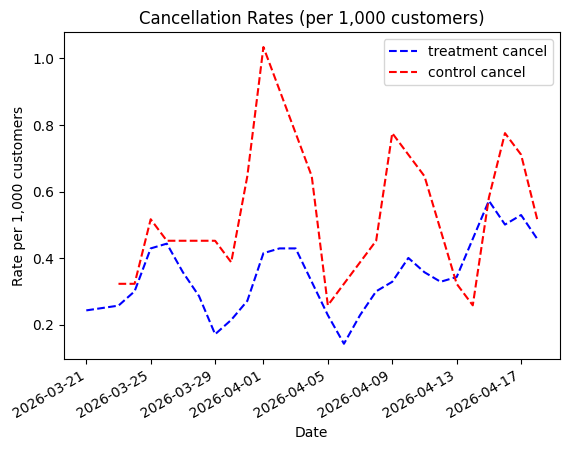

In [68]:
import matplotlib.pyplot as plt

# window
start = pd.Timestamp("2026-03-19")
end = pd.Timestamp("2026-04-18")

# group sizes
n_treat = (df_model["treatment"] == 1).sum()
n_control = (df_model["treatment"] == 0).sum()


# --- CANCEL DATE ---
df_cancel = df_kuend_clean.merge(
    df_model[["customer_id", "treatment"]],
    on="customer_id",
    how="left"
)

df_cancel["cancel_date"] = pd.to_datetime(
    df_cancel["cancel_date"],
    dayfirst=True,
    errors="coerce"
)

df_cancel = df_cancel[
    (df_cancel["cancel_date"] >= start) &
    (df_cancel["cancel_date"] <= end)
]

treat_cancel = (
    df_cancel[df_cancel["treatment"] == 1]["cancel_date"]
    .value_counts()
    .sort_index()
    .rolling(3).mean()
) / n_treat * 1000

control_cancel = (
    df_cancel[df_cancel["treatment"] == 0]["cancel_date"]
    .value_counts()
    .sort_index()
    .rolling(3).mean()
) / n_control * 1000


# --- PLOT ---
plt.figure()

# cancel (dashed)
treat_cancel.plot(label="treatment cancel", linestyle="--", color="blue")
control_cancel.plot(label="control cancel", linestyle="--", color="red")

plt.title("Cancellation Rates (per 1,000 customers)")
plt.xlabel("Date")
plt.ylabel("Rate per 1,000 customers")
plt.legend()

plt.show()

MÜLL






-
-
-


In [69]:
df_model.head(5)

,customer_id,treatment,contract_with_device,payment_method,billing_freq,age_bin,gender,milieu,cluster,has_phone,current_tenure,total_tenure,tenure_start_date,tenure_ratio,email_optout,churn,negative_outcome,email_clicked,email_opened
0,0018640485,0,0,SEPA,M,"(65, 75]",female,PMA,Floh,0,3.23,3.34,2012-10-25,0.967066,0,0,0,0,0
1,0018703242,0,0,Invoice,M,"(55, 65]",female,PER,Floh,0,6.64,6.83,2013-06-10,0.972182,0,0,0,0,0
2,0019173245,0,0,SEPA,M,"(55, 65]",female,NOK,Floh,0,6.42,6.71,2019-03-05,0.956781,0,0,0,0,0
3,0019173659,0,0,SEPA,M,"(75, 100]",male,PER,Seehund,0,7.00,7.00,2019-03-01,1.000000,0,0,0,0,0
4,0019173423,0,0,SEPA,M,"(75, 100]",female,EPE,Elefant,0,7.15,7.15,2019-03-01,1.000000,0,0,0,0,0


In [70]:
from lightgbm import LGBMClassifier

# split in train
X_treat = X_train[t_train == 1]
y_treat = y_train[t_train == 1]

X_ctrl = X_train[t_train == 0]
y_ctrl = y_train[t_train == 0]

m_treat = LGBMClassifier(
    class_weight="balanced",
    n_estimators=100,
    max_depth=4,
    random_state=42
)

m_ctrl = LGBMClassifier(
    class_weight="balanced",
    n_estimators=100,
    max_depth=4,
    random_state=42
)

m_treat.fit(X_treat, y_treat)
m_ctrl.fit(X_ctrl, y_ctrl)

[LightGBM] [Info] Number of positive: 183, number of negative: 16124
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000426 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 831
[LightGBM] [Info] Number of data points in the train set: 16307, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

LGBMClassifier(class_weight='balanced', max_depth=4, random_state=42)

In [71]:
uplift_test = (
    m_treat.predict_proba(X_test)[:, 1] -
    m_ctrl.predict_proba(X_test)[:, 1]
)

df_test = X_test.copy()
df_test["uplift_tlearner"] = uplift_test
df_test["y"] = y_test
df_test["t"] = t_test

print(df_test["uplift_tlearner"].describe())

count    8538.000000
mean        0.162371
std         0.241189
min        -0.832012
25%         0.015961
50%         0.150581
75%         0.325129
max         0.914204
Name: uplift_tlearner, dtype: float64


In [72]:
df_test["decile"] = pd.qcut(df_test["uplift_tlearner"], 10, labels=False)

df_test.groupby("decile")["y"].mean()

decile
0    0.012881
1    0.008187
2    0.010551
3    0.008206
4    0.009368
5    0.004684
6    0.010551
7    0.010539
8    0.009368
9    0.024590
Name: y, dtype: float64

## uplift = P(churn | email) − P(churn | no email)

### do NOT write

In [73]:
df_test = df_test.copy()
df_test["customer_id"] = df_model.loc[df_test.index, "customer_id"]

df_test.sort_values("uplift_tlearner", ascending=False)[
    ["customer_id", "uplift_tlearner"]
].head(10)

,customer_id,uplift_tlearner
18863,0016551346,0.914204
19105,0016582531,0.874340
17381,0016323172,0.871983
15271,0016032644,0.863252
9402,0017649779,0.856051
16679,0018168950,0.851252
9806,0018352481,0.850332
9323,0018269086,0.844381
4780,0019573483,0.841118
22440,0018267473,0.835290


### write

In [74]:
df_test.sort_values("uplift_tlearner", ascending=True)[
    ["customer_id", "uplift_tlearner"]
].head(10)

,customer_id,uplift_tlearner
6349,0016205907,-0.832012
16484,0016234971,-0.797350
14205,0017042176,-0.796962
13584,0016023570,-0.793562
38,0016002014,-0.784149
11429,0016019409,-0.784149
19608,0016048546,-0.774060
9367,0016220304,-0.764256
14476,0016244542,-0.752985
5112,0019616118,-0.750438


In [75]:
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor

cf = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=50),
    model_t=RandomForestRegressor(n_estimators=50),
    discrete_treatment=True,
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

cf.fit(y, t, X=X)

uplift_cf = cf.effect(X)

df_model["uplift_cf"] = uplift_cf

print(df_model["uplift_cf"].describe())

d:\ДАША\УЧЕБА\!!BACHELOR\Model\Code\Bachelorarbeit\.venv\Lib\site-packages\econml\dml\dml.py:51: UserWarning: First stage model has discrete target but model is not a classifier!
  warn('First stage model has discrete target but model is not a classifier!', UserWarning)
d:\ДАША\УЧЕБА\!!BACHELOR\Model\Code\Bachelorarbeit\.venv\Lib\site-packages\econml\dml\dml.py:51: UserWarning: First stage model has discrete target but model is not a classifier!
  warn('First stage model has discrete target but model is not a classifier!', UserWarning)


count    28457.000000
mean         0.000408
std          0.014550
min         -0.243541
25%         -0.004310
50%         -0.000558
75%          0.004921
max          0.177014
Name: uplift_cf, dtype: float64


In [76]:
# define observation window for post-campaign churn
start = pd.Timestamp("2026-03-19")
end = pd.Timestamp("2026-04-19")

# create churn variable: 1 if subscription ended within the observation window
df["churn"] = (
    df["end_date"].notna() &
    (df["end_date"] >= start) &
    (df["end_date"] <= end)
).astype(int)

# overall churn rate (%)
churn = df["churn"].value_counts()
overall_churn = df["churn"].mean() * 100

# overall churn by treatment group (%)
churn_by_group = df.groupby("treatment")["churn"].mean() * 100
churn_by_group.index = ["Not sent", "Sent"]

# KA churn based on the same base: all customers in each group
ka_churn_by_group = df.groupby("treatment").apply(
    lambda x: ((x["churn"] == 1) & (x["cancel_reason"] == "KA")).mean() * 100
)
ka_churn_by_group.index = ["Not sent", "Sent"]

# share of KA among all churned customers (%)
ka_share_among_churned = (
    (df.loc[df["churn"] == 1, "cancel_reason"] == "KA").mean() * 100
)

# print results
print(f"Overall churn: {churn}\n")
print(f"Overall churn: {overall_churn:.4f}%\n")

print("Overall churn by treatment group (%):")
print(churn_by_group.round(4))

print("\nKA churn by treatment group (% of all customers):")
print(ka_churn_by_group.round(4))

print(f"\nShare of KA among all churned customers: {ka_share_among_churned:.4f}%")

Overall churn: churn
0    28255
1      202
Name: count, dtype: int64

Overall churn: 0.7098%

Overall churn by treatment group (%):
Not sent    0.9690
Sent        0.6524
Name: churn, dtype: float64

KA churn by treatment group (% of all customers):
Not sent    0.1357
Sent        0.2189
dtype: float64

Share of KA among all churned customers: 28.7129%


In [77]:
df_check = df[[
    "customer_id",
    "start_date",
    "end_date",
    "cancel_date",
    "cancel_reason",
    "last_activity"
]].copy()

# только где есть обе даты
df_both = df_check.dropna(subset=["end_date", "cancel_date", "last_activity"])

len(df)
df["last_activity"].notna().sum()
len(df_both)

KeyError: "['last_activity'] not in index"

In [ ]:
# define observation window for post-campaign churn
start = pd.Timestamp("2026-03-19")
end = pd.Timestamp("2026-04-19")

# create churn variable: 1 if subscription ended within the observation window
df["churn"] = (
    df["end_date"].notna() &
    (df["end_date"] >= start) &
    (df["end_date"] <= end)
).astype(int)

# overall churn rate (%)
overall_churn = df["churn"].mean() * 100

# overall churn by treatment group (%)
churn_by_group = df.groupby("treatment")["churn"].mean() * 100
churn_by_group.index = ["Not sent", "Sent"]

# KA churn based on the same base: all customers in each group
ka_churn_by_group = df.groupby("treatment").apply(
    lambda x: ((x["churn"] == 1) & (x["cancel_reason"] == "KA")).mean() * 100
)
ka_churn_by_group.index = ["Not sent", "Sent"]

# share of KA among all churned customers (%)
ka_share_among_churned = (
    (df.loc[df["churn"] == 1, "cancel_reason"] == "KA").mean() * 100
)

# print results
print(f"Overall churn: {overall_churn:.4f}%\n")

print("Overall churn by treatment group (%):")
print(churn_by_group.round(4))

print("\nKA churn by treatment group (% of all customers):")
print(ka_churn_by_group.round(4))

print(f"\nShare of KA among all churned customers: {ka_share_among_churned:.4f}%")

Overall churn: 0.7098%

Overall churn by treatment group (%):
Not sent    0.9690
Sent        0.6524
Name: churn, dtype: float64

KA churn by treatment group (% of all customers):
Not sent    0.1357
Sent        0.2189
dtype: float64

Share of KA among all churned customers: 28.7129%


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# Große der Gruppe
n_control = (df["treatment"] == 0).sum()
n_treat = (df["treatment"] == 1).sum()

# Anzahl churn
churn_control = df.loc[df["treatment"] == 0, "churn"].sum()
churn_treat = df.loc[df["treatment"] == 1, "churn"].sum()

# delta
delta = (churn_treat / n_treat) - (churn_control / n_control)

# z-test
stat, pval = proportions_ztest(
    [churn_treat, churn_control],
    [n_treat, n_control]
)

print(f"Delta Kündigungsrate: {delta*100:.4f} pp")
print(f"Z-stat: {stat:.4f}")
print(f"P-value: {pval:.4f}")

Delta Kündigungsrate: -0.3165 pp
Z-stat: -2.4507
P-value: 0.0143


In [ ]:
# define observation window for post-campaign churn
start = pd.Timestamp("2026-03-19")
end = pd.Timestamp("2026-04-19")

# create churn variable: 1 if subscription ended within the observation window
df["churn"] = (
    df["cancel_date"].notna() &
    (df["cancel_date"] >= start) &
    (df["cancel_date"] <= end)
).astype(int)

# overall churn rate (%)
overall_churn = df["churn"].mean() * 100

# overall churn by treatment group (%)
churn_by_group = df.groupby("treatment")["churn"].mean() * 100
churn_by_group.index = ["Not sent", "Sent"]

# KA churn based on the same base: all customers in each group
ka_churn_by_group = df.groupby("treatment").apply(
    lambda x: ((x["churn"] == 1) & (x["cancel_reason"] == "KA")).mean() * 100
)
ka_churn_by_group.index = ["Not sent", "Sent"]

# share of KA among all churned customers (%)
ka_share_among_churned = (
    (df.loc[df["churn"] == 1, "cancel_reason"] == "KA").mean() * 100
)

# print results
print(f"Overall churn: {overall_churn:.4f}%\n")

print("Overall churn by treatment group (%):")
print(churn_by_group.round(4))

print("\nKA churn by treatment group (% of all customers):")
print(ka_churn_by_group.round(4))

print(f"\nShare of KA among all churned customers: {ka_share_among_churned:.4f}%")

Overall churn: 1.1069%

Overall churn by treatment group (%):
Not sent    1.2984
Sent        1.0645
Name: churn, dtype: float64

KA churn by treatment group (% of all customers):
Not sent    0.3682
Sent        0.3305
dtype: float64

Share of KA among all churned customers: 30.4762%


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# Große der Gruppe
n_control = (df["treatment"] == 0).sum()
n_treat = (df["treatment"] == 1).sum()

# Anzahl churn
churn_control = df.loc[df["treatment"] == 0, "churn"].sum()
churn_treat = df.loc[df["treatment"] == 1, "churn"].sum()

# delta
delta = (churn_treat / n_treat) - (churn_control / n_control)

# z-test
stat, pval = proportions_ztest(
    [churn_treat, churn_control],
    [n_treat, n_control]
)

print(f"Delta Kündigungsrate: {delta*100:.4f} pp")
print(f"Z-stat: {stat:.4f}")
print(f"P-value: {pval:.4f}")

Delta Kündigungsrate: -0.2339 pp
Z-stat: -1.4532
P-value: 0.1462


In [ ]:
# --- Activity segmentation (correct column name) ---

# parse
df["last_activity"] = pd.to_datetime(
    df["last_activity"],
    errors="coerce",
    dayfirst=True
)

# days since last activity
campaign_date = pd.Timestamp("2026-03-19")

df["days_since_activity"] = (
    campaign_date - df["last_activity"]
).dt.days

# фильтр: не заходил больше недели
df_pre = df[df["days_since_activity"] > 0].copy()

df_pre["activity_group"] = pd.cut(
    df_pre["days_since_activity"],
    bins=[0, 7, 30, 10000],
    labels=["active", "less_active", "inactive"]
)

df_pre.groupby("activity_group")["churn"].mean() * 100
df["churn"].value_counts()


KeyError: 'last_activity'

In [ ]:
# filter only customers who churned in the campaign window
df_window = df[
    (df["churn"] == 1)
].copy()

# count per cancel_reason (only in this month)
counts = df_window["cancel_reason"].value_counts()

# one example customer per reason
examples = (
    df_window[["cancel_reason", "customer_id"]]
    .dropna(subset=["cancel_reason"])
    .drop_duplicates(subset=["cancel_reason"])
    .set_index("cancel_reason")
)

# combine
df_reason_map = (
    counts.to_frame("count")
    .join(examples)
    .reset_index()
    .rename(columns={"index": "cancel_reason"})
)
df_window.groupby(["treatment", "cancel_reason"]).size().reset_index(name="count")

df_reason_map


KeyError: 'churn'

In [ ]:
churn_end = (
    df["end_date"].notna() &
    (df["end_date"] >= start) &
    (df["end_date"] <= end)
).astype(int)

churn_cancel = (
    df["cancel_date"].notna() &
    (df["cancel_date"] >= start) &
    (df["cancel_date"] <= end)
).astype(int)

print((churn_end != churn_cancel).sum())
df["lag_days"] = (df["end_date"] - df["cancel_date"]).dt.days
df["lag_days"].describe()

521


count    411.000000
mean      87.518248
std      130.139031
min       -1.000000
25%       23.000000
50%       29.000000
75%       85.000000
max      680.000000
Name: lag_days, dtype: float64

lag_days
-1.0      5
 0.0     22
 1.0      3
 2.0      1
 5.0      1
 6.0      9
 9.0      4
 10.0     3
 11.0     1
 12.0     1
 13.0     3
 14.0     5
 15.0     5
 16.0     7
 17.0     9
 20.0    10
 21.0     7
 22.0     3
 23.0     6
 24.0     6
Name: count, dtype: int64

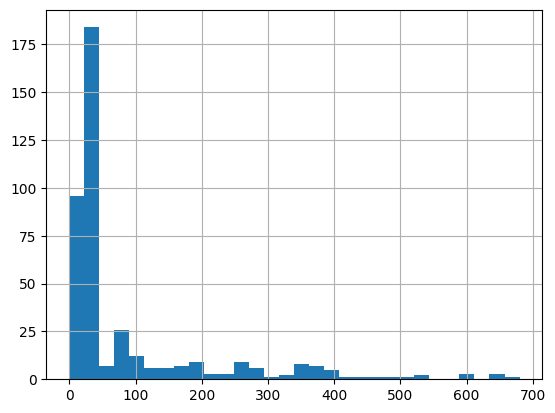

In [ ]:
df["lag_days"] = (df["end_date"] - df["cancel_date"]).dt.days
df["lag_days"].describe()
df["lag_days"].hist(bins=30)
df["lag_days"].value_counts().sort_index().head(20)